In [62]:
%pylab inline
import pandas as pd

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


/root/micromamba/lib/python3.13/site-packages/IPython/core/magics/pylab.py:166: UserWarning: pylab import has clobbered these variables: ['inf']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


In [63]:
def read_merged(path="../z30"):
    from pathlib import Path
    path = Path(path)
    df = pd.read_csv(path / "AssociatedResults/sim_merged.csv" )
    df["ev/Δx"] = ((df["ev/x"]-255/2)*120/256)- df["sim/px"]
    df["px/Δx"] = ((df["px/x"]-255/2)*120/256)- df["sim/px"]
    df["ph/Δx"] = ((df["ph/x"]-255/2)*120/256)- df["sim/px"]
    
    df["ev/Δtoa"] = df["ev/toa"]- df["sim/toa"]*1e-9
    df["px/Δtoa"] = df["px/toa"]- df["sim/toa"]*1e-9
    df["ph/Δtoa"] = df["ph/toa"]- df["sim/toa"]*1e-9
    
    df["ev/n"] = df.groupby("ev/id")["ph/id"].transform("nunique")
    df["ph/n"] = df.groupby("ph/id")["px/id"].transform("nunique")

    df["dz"] = pd.cut(df["sim/pz"],arange(0,21,2),labels=arange(0,20,2))

    df.name = path.stem
    return df

In [67]:
oof = read_merged("archive/openbeam_ptb_5e6/out_of_focus/")
inf = read_merged("archive/openbeam_ptb_5e6/in_focus/")

<Axes: xlabel='sim/pz', ylabel='ev/Δx'>

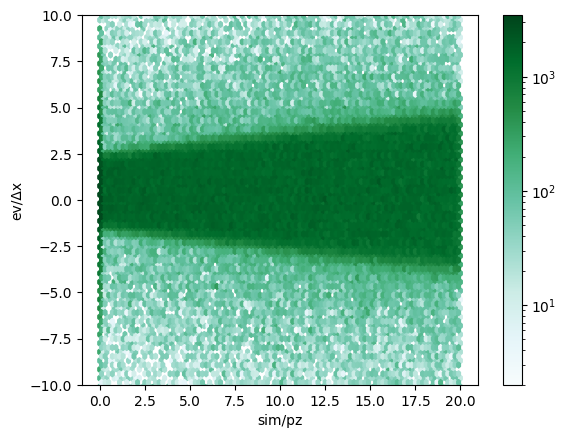

In [68]:
oof.plot.hexbin(x="sim/pz",y="ev/Δx",bins="log",ylim=(-10,10),gridsize=(100,500))

<Axes: xlabel='sim/pz', ylabel='ev/Δx'>

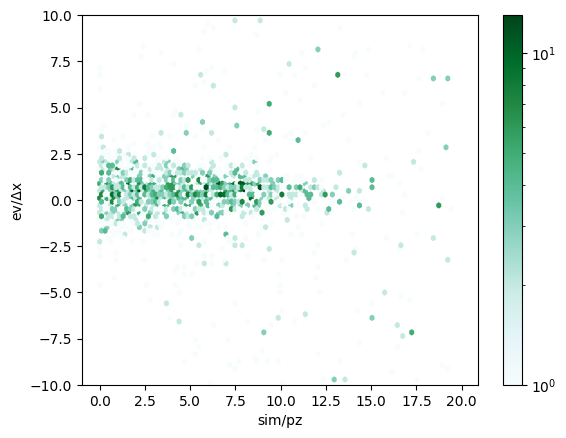

In [66]:
inf.plot.hexbin(x="sim/pz",y="ev/Δx",bins="log",ylim=(-10,10),gridsize=(100,500))

<Axes: xlabel='sim/pz', ylabel='ev/Δx'>

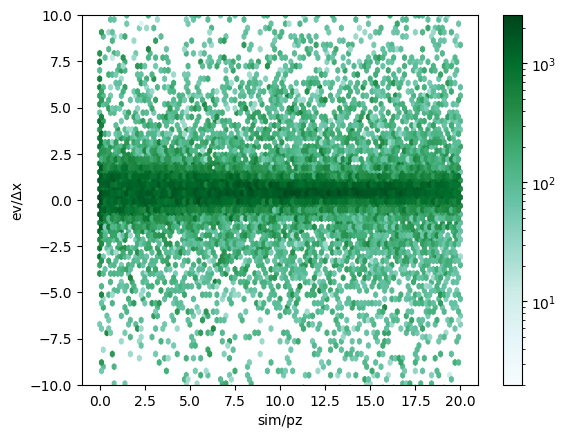

In [40]:
oof.plot.hexbin(x="sim/pz",y="ev/Δx",bins="log",ylim=(-10,10),gridsize=(100,500))

<Axes: ylabel='Frequency'>

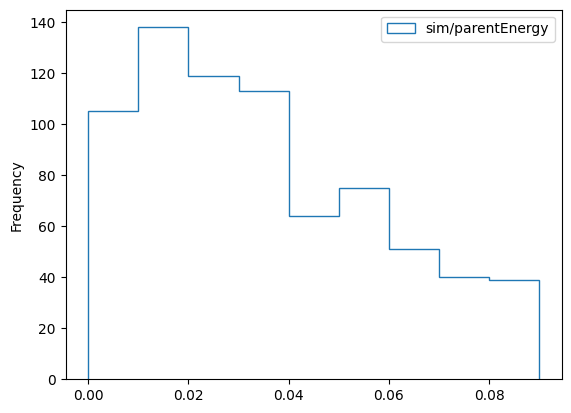

In [56]:
inf.plot.hist(y="sim/parentEnergy",bins=arange(0,0.1,0.01),histtype="step")

<Axes: xlabel='sim/parentEnergy', ylabel='sim/neutronEnergy'>

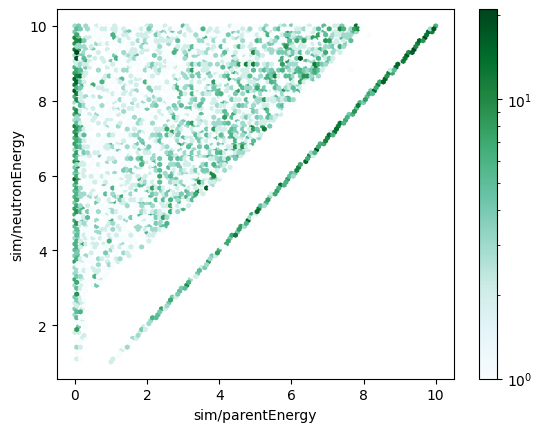

In [57]:
inf.plot.hexbin(x="sim/parentEnergy",y="sim/neutronEnergy",bins="log")#,ylim=(-10,10),gridsize=(100,500))

<Axes: xlabel='sim/pz', ylabel='ev/Δx'>

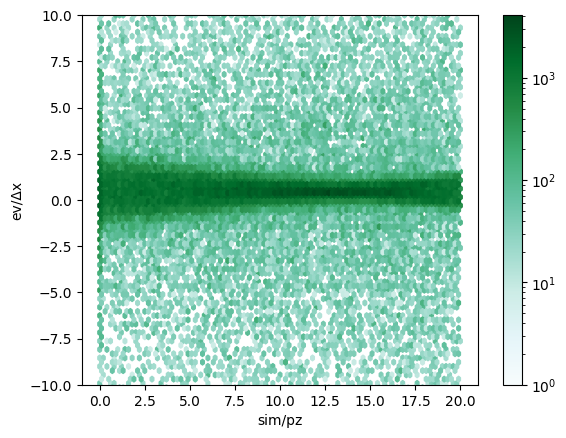

In [5]:
inf.plot.hexbin(x="sim/pz",y="ev/Δx",bins="log",ylim=(-10,10),gridsize=(100,500))

<Axes: xlabel='sim/parentEnergy', ylabel='ev/Δx'>

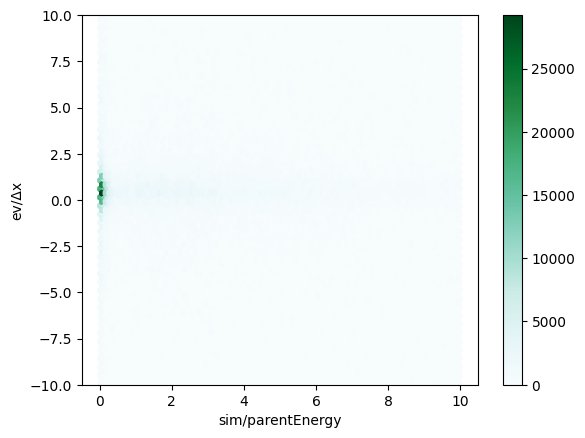

In [52]:
oof.plot.hexbin(x="sim/parentEnergy",y="ev/Δx",ylim=(-10,10),gridsize=(100,500))

/tmp/ipykernel_125112/3073564980.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  oof.query("-4<`ev/Δx`<4").groupby("dz")["ev/Δx"].std().plot(ax=gca())
/tmp/ipykernel_125112/3073564980.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  inf.query("-4<`ev/Δx`<4").groupby("dz")["ev/Δx"].std().plot(ax=gca())


<Axes: xlabel='dz'>

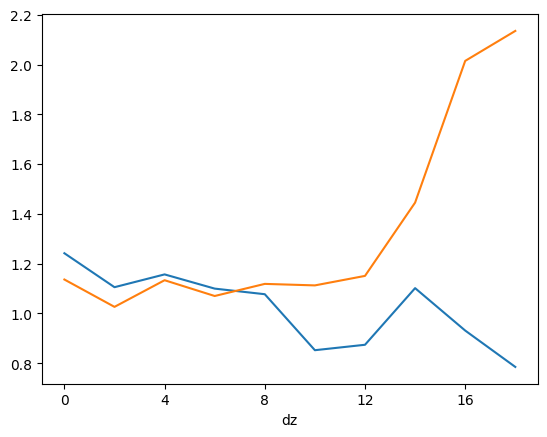

In [58]:

oof.query("-4<`ev/Δx`<4").groupby("dz")["ev/Δx"].std().plot(ax=gca())
inf.query("-4<`ev/Δx`<4").groupby("dz")["ev/Δx"].std().plot(ax=gca())

/tmp/ipykernel_125112/1481696765.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  oof.groupby("dz").plot.hist(y="ev/Δx",bins=arange(-10,10,0.1),histtype="step",ax=gca(),logy=False,density=True)


dz
0     Axes(0.125,0.11;0.775x0.77)
10    Axes(0.125,0.11;0.775x0.77)
dtype: object

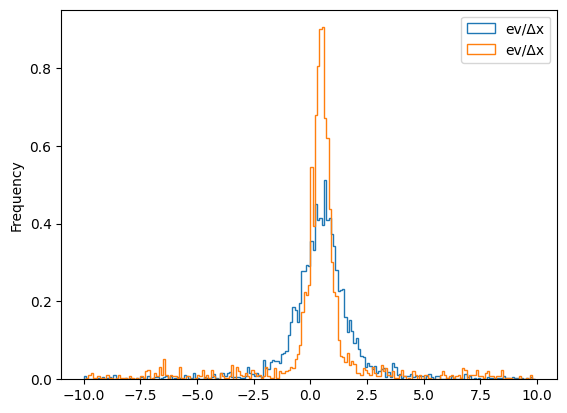

In [59]:
oof["dz"] = pd.cut(oof["sim/pz"],arange(0,21,10),labels=arange(0,20,10))
oof.groupby("dz").plot.hist(y="ev/Δx",bins=arange(-10,10,0.1),histtype="step",ax=gca(),logy=False,density=True)
# df.query("`sim/parentName`=='e-'").groupby("dz").plot.hist(y="ev/Δx",bins=arange(-10,10,0.5),histtype="step",ax=gca(),logy=False,ls="--",density=True)

/tmp/ipykernel_125112/1481696765.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  oof.groupby("dz").plot.hist(y="ev/Δx",bins=arange(-10,10,0.1),histtype="step",ax=gca(),logy=False,density=True)


dz
0     Axes(0.125,0.11;0.775x0.77)
10    Axes(0.125,0.11;0.775x0.77)
dtype: object

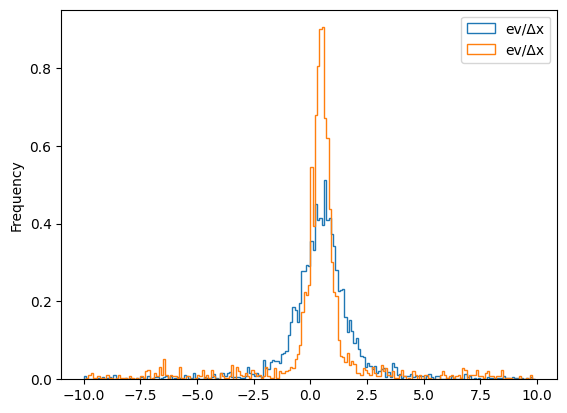

In [60]:
oof["dz"] = pd.cut(oof["sim/pz"],arange(0,21,10),labels=arange(0,20,10))
oof.groupby("dz").plot.hist(y="ev/Δx",bins=arange(-10,10,0.1),histtype="step",ax=gca(),logy=False,density=True)
# df.query("`sim/parentName`=='e-'").groupby("dz").plot.hist(y="ev/Δx",bins=arange(-10,10,0.5),histtype="step",ax=gca(),logy=False,ls="--",density=True)

/tmp/ipykernel_149774/1193086978.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  inf.groupby("dE").plot.hist(y="ph/Δx",bins=arange(-10,10,0.1),histtype="step",ax=gca(),logy=True,density=True)


dE
0.00    Axes(0.125,0.11;0.775x0.77)
0.02    Axes(0.125,0.11;0.775x0.77)
0.10    Axes(0.125,0.11;0.775x0.77)
1.00    Axes(0.125,0.11;0.775x0.77)
5.00    Axes(0.125,0.11;0.775x0.77)
dtype: object

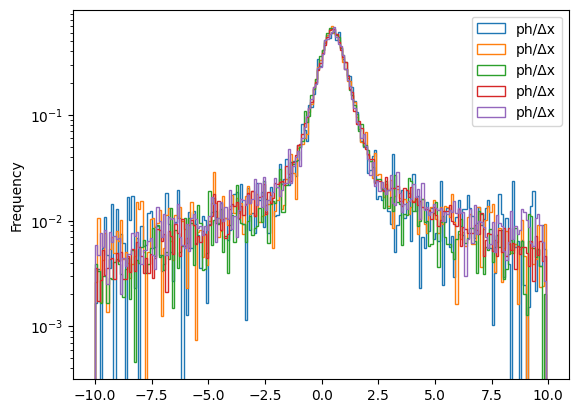

In [49]:
ebins = [0,0.02,0.1,1,5,10]
inf["dE"] = pd.cut(inf["sim/parentEnergy"],ebins,labels=ebins[:-1])
inf.groupby("dE").plot.hist(y="ph/Δx",bins=arange(-10,10,0.1),histtype="step",ax=gca(),logy=True,density=True)

/tmp/ipykernel_125112/3829202157.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  inf.groupby("dz").plot.hist(y="ev/Δx",bins=arange(-10,10,0.1),histtype="step",ax=gca(),logy=False,density=True)


dz
0     Axes(0.125,0.11;0.775x0.77)
10    Axes(0.125,0.11;0.775x0.77)
dtype: object

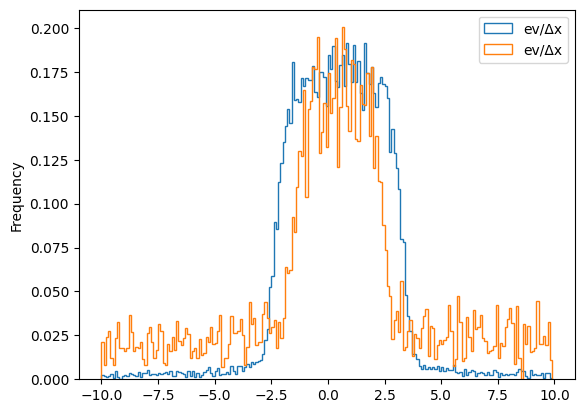

In [11]:
inf["dz"] = pd.cut(inf["sim/pz"],arange(0,21,10),labels=arange(0,20,10))
inf.groupby("dz").plot.hist(y="ev/Δx",bins=arange(-10,10,0.1),histtype="step",ax=gca(),logy=False,density=True)
# df.query("`sim/parentName`=='e-'").groupby("dz").plot.hist(y="ev/Δx",bins=arange(-10,10,0.5),histtype="step",ax=gca(),logy=False,ls="--",density=True)

In [40]:
oof.query("`sim/parentEnergy`<0.1").groupby("sim/parentName")["sim/nz"].describe()

,count,mean,std,min,25%,50%,75%,max
sim/parentName,,,,,,,,
e-,363.0,-10850.000000,0.000000,-10850.0,-10850.0000,-10850.0000,-10850.0000,-10850.0000
proton,330788.0,-684.603022,2658.783245,-10850.0,4.2809,10.5425,16.0461,19.9986


In [120]:
inf.groupby("sim/parentName")["sim/nz"].describe()

,count,mean,std,min,25%,50%,75%,max
sim/parentName,,,,,,,,
Be9,116.0,8.756800,2.549186,4.6874,7.6121,9.57555,10.720250,11.1887
C12,7450.0,-497.371470,2291.819813,-10850.0000,3.7814,9.53680,15.387400,19.8974
C13,95.0,6.574905,6.021514,2.6045,2.6045,2.60450,15.611000,15.6110
alpha,232.0,6.454200,6.258951,0.1123,1.9328,3.20800,11.214525,18.9892
e+,564.0,-10850.000000,0.000000,-10850.0000,-10850.0000,-10850.00000,-10850.000000,-10850.0000
e-,20746.0,-7936.412600,4811.748101,-10850.0000,-10850.0000,-10850.00000,1.447300,19.7108
proton,201263.0,-523.227756,2348.103135,-10850.0000,4.5070,10.71780,15.760100,19.9986


In [122]:
oof.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230508 entries, 0 to 230507
Data columns (total 46 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   px/id              230508 non-null  int64   
 1   sim/toa2           230466 non-null  float64 
 2   sim/toa_tick       230466 non-null  float64 
 3   sim/id             230466 non-null  float64 
 4   sim/neutron_id     230466 non-null  float64 
 5   sim/pulse_id       230466 non-null  float64 
 6   sim/pulse_time_ns  230466 non-null  float64 
 7   sim/wavelength     230466 non-null  float64 
 8   sim/parentName     230466 non-null  object  
 9   sim/parentEnergy   230466 non-null  float64 
 10  sim/neutronEnergy  230466 non-null  float64 
 11  sim/x              230466 non-null  float64 
 12  sim/y              230466 non-null  float64 
 13  sim/z              230466 non-null  float64 
 14  sim/toa            230466 non-null  float64 
 15  sim/px             230466 non-null

In [124]:
inf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230508 entries, 0 to 230507
Data columns (total 46 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   px/id              230508 non-null  int64   
 1   sim/toa2           230466 non-null  float64 
 2   sim/toa_tick       230466 non-null  float64 
 3   sim/id             230466 non-null  float64 
 4   sim/neutron_id     230466 non-null  float64 
 5   sim/pulse_id       230466 non-null  float64 
 6   sim/pulse_time_ns  230466 non-null  float64 
 7   sim/wavelength     230466 non-null  float64 
 8   sim/parentName     230466 non-null  object  
 9   sim/parentEnergy   230466 non-null  float64 
 10  sim/neutronEnergy  230466 non-null  float64 
 11  sim/x              230466 non-null  float64 
 12  sim/y              230466 non-null  float64 
 13  sim/z              230466 non-null  float64 
 14  sim/toa            230466 non-null  float64 
 15  sim/px             230466 non-null

<Axes: xlabel='ph/n', ylabel='ph/Δtoa'>

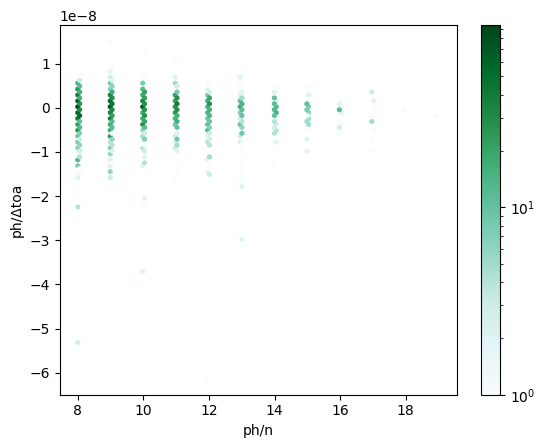

In [61]:
inf.query("-1e-7<`ev/Δtoa`<1e-7").plot.hexbin(x="ph/n",y="ph/Δtoa",bins="log")

<Axes: xlabel='ph/n', ylabel='ph/Δtoa'>

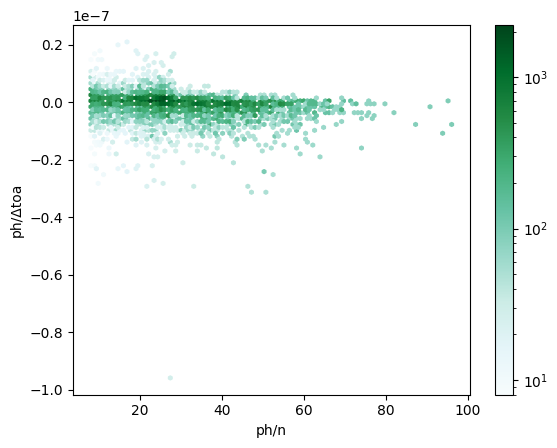

In [126]:
inf.query("-1e-7<`ev/Δtoa`<1e-7").plot.hexbin(x="ph/n",y="ph/Δtoa",bins="log")

<Axes: xlabel='px/tof', ylabel='ev/Δtoa'>

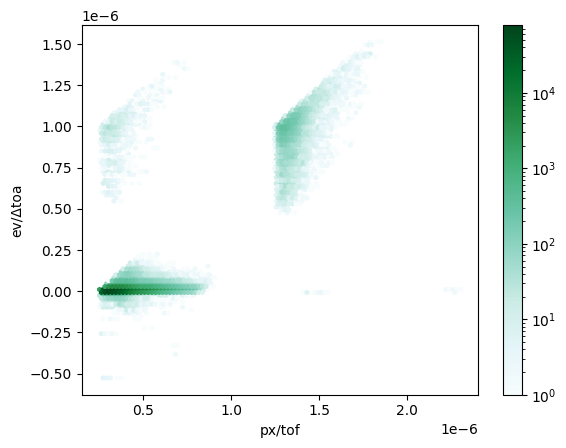

In [19]:
oof.query("-1e-6<`ev/Δtoa`<1e-5 and `px/tof`<3e-6").plot.hexbin(x="px/tof",y="ev/Δtoa",bins="log")

<Axes: xlabel='px/tof', ylabel='ev/Δtoa'>

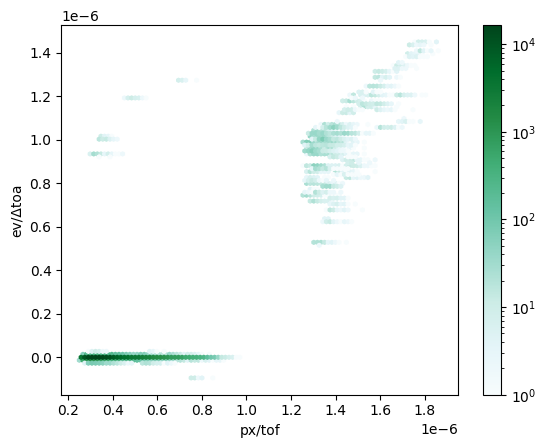

In [146]:
inf.query("-1e-6<`ev/Δtoa`<1e-4").plot.hexbin(x="px/tof",y="ev/Δtoa",bins="log")

<Axes: ylabel='Frequency'>

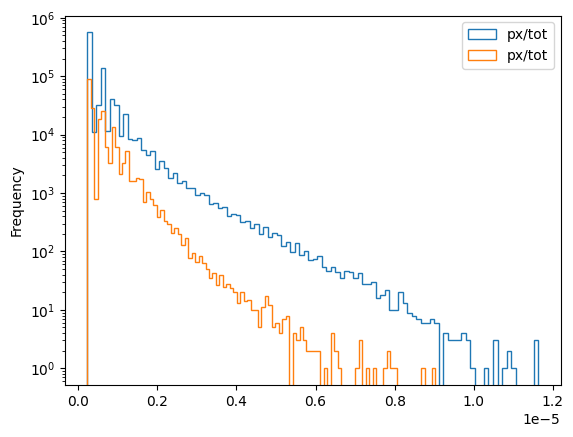

In [20]:
oof.dropna().plot.hist(y=["px/tot"],bins=100,histtype="step",logy=True,ax=gca())
inf.dropna().plot.hist(y=["px/tot"],bins=100,histtype="step",logy=True,ax=gca())

<Axes: ylabel='Frequency'>

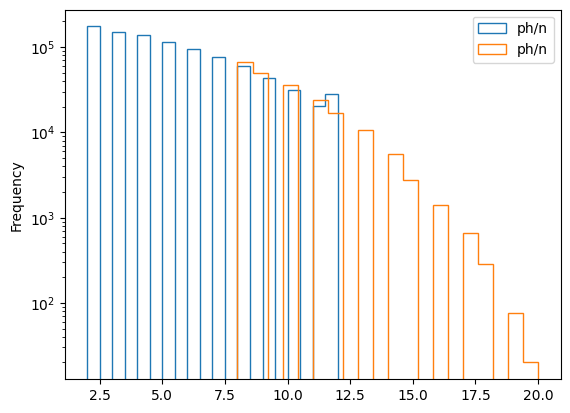

In [21]:
oof.dropna().plot.hist(y=["ph/n"],bins=20,histtype="step",logy=True,ax=gca())
inf.dropna().plot.hist(y=["ph/n"],bins=20,histtype="step",logy=True,ax=gca())

<Axes: ylabel='Frequency'>

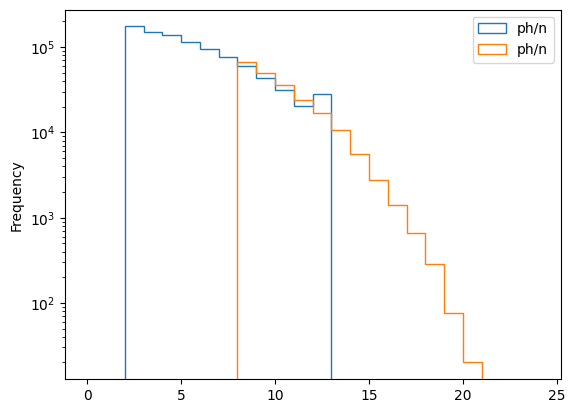

In [23]:
oof.dropna().plot.hist(y=["ph/n"],bins=arange(0,25,1),histtype="step",logy=True,ax=gca())
inf.dropna().plot.hist(y=["ph/n"],bins=arange(0,25,1),histtype="step",logy=True,ax=gca())

<Axes: ylabel='Frequency'>

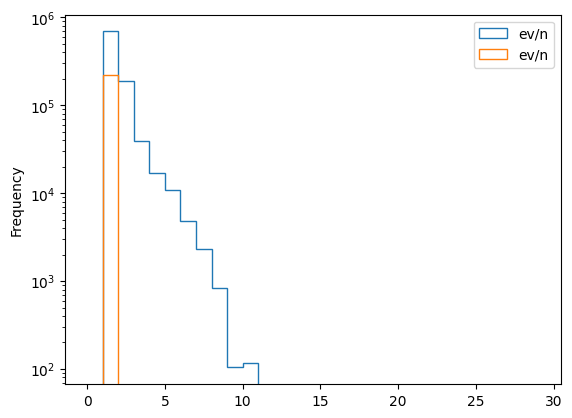

In [24]:
oof.plot.hist(y=["ev/n"],bins=arange(30),histtype="step",logy=True,ax=gca())
inf.plot.hist(y=["ev/n"],bins=arange(30),histtype="step",logy=True,ax=gca())

<Axes: ylabel='Frequency'>

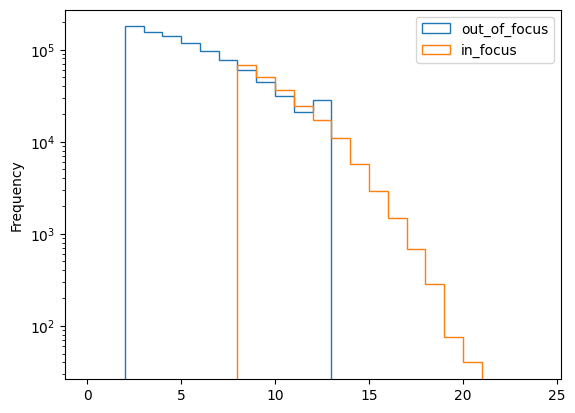

In [26]:
oof.plot.hist(y="ph/n",bins=arange(25),histtype="step",logy=True,ax=gca(),label=oof.name)
inf.plot.hist(y="ph/n",bins=arange(25),histtype="step",logy=True,ax=gca(),label=inf.name)

<Axes: ylabel='Frequency'>

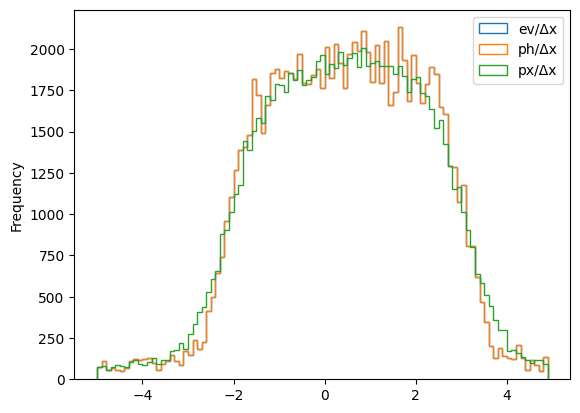

In [28]:
inf.query("`ph/n`<10").plot.hist(y=["ev/Δx","ph/Δx","px/Δx"],bins=arange(-5,5,0.1),histtype="step",logy=False)

In [12]:
df.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238571 entries, 0 to 238570
Data columns (total 43 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   px/id              238571 non-null  int64  
 1   sim/toa2           238496 non-null  float64
 2   sim/toa_tick       238496 non-null  float64
 3   sim/id             238496 non-null  float64
 4   sim/neutron_id     238496 non-null  float64
 5   sim/pulse_id       238496 non-null  float64
 6   sim/pulse_time_ns  238496 non-null  float64
 7   sim/wavelength     238496 non-null  float64
 8   sim/parentName     238496 non-null  object 
 9   sim/parentEnergy   238496 non-null  float64
 10  sim/neutronEnergy  238496 non-null  float64
 11  sim/x              238496 non-null  float64
 12  sim/y              238496 non-null  float64
 13  sim/z              238496 non-null  float64
 14  sim/toa            238496 non-null  float64
 15  sim/px             238496 non-null  float64
 16  si

<Axes: ylabel='Frequency'>

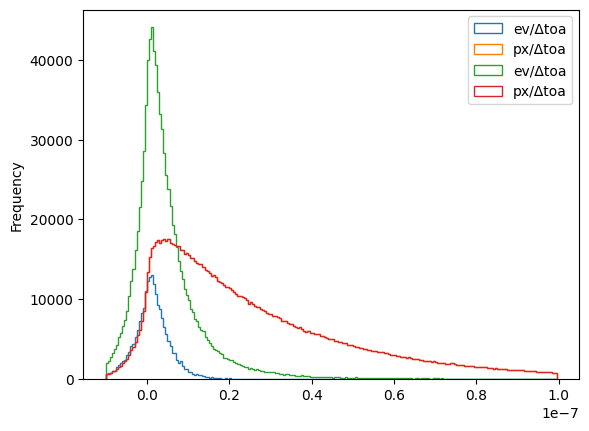

In [36]:
inf.plot.hist(y=["ev/Δtoa","px/Δtoa"],bins=arange(-1e-8,1e-7,5e-10),histtype="step",logy=False)
oof.plot.hist(y=["ev/Δtoa","px/Δtoa"],bins=arange(-1e-8,1e-7,5e-10),histtype="step",logy=False,ax=gca())

<Axes: ylabel='Frequency'>

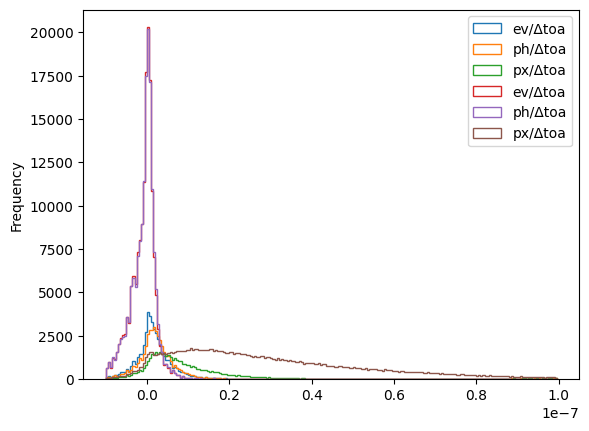

In [101]:
df.query("`ph/n`<10").plot.hist(y=["ev/Δtoa","ph/Δtoa","px/Δtoa"],bins=arange(-1e-8,1e-7,5e-10),histtype="step",logy=False,ax=gca())
df.query("`ph/n`>10").plot.hist(y=["ev/Δtoa","ph/Δtoa","px/Δtoa"],bins=arange(-1e-8,1e-7,5e-10),histtype="step",logy=False,ax=gca())

<Axes: ylabel='Frequency'>

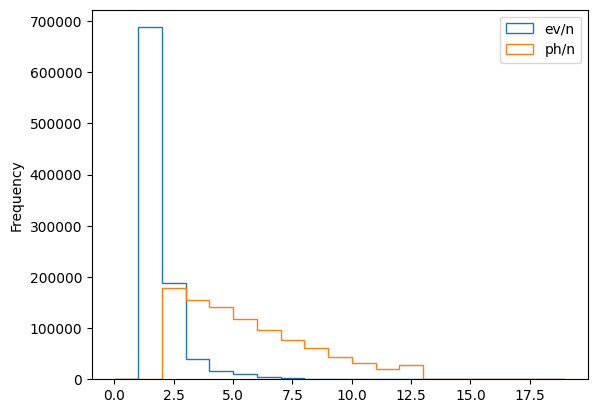

In [41]:
oof.plot.hist(y=["ev/n","ph/n"],bins=arange(20),histtype="step",logy=False)

<Axes: ylabel='Frequency'>

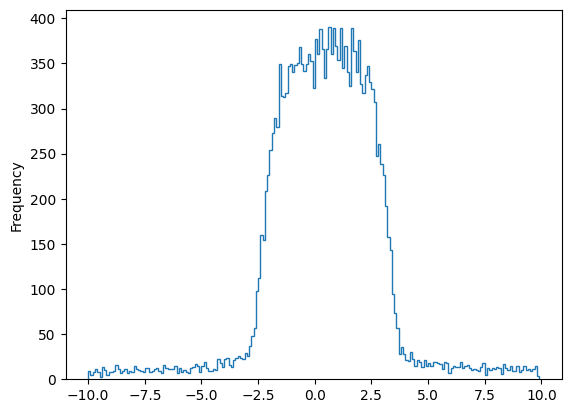

In [43]:
inf.groupby("ev/id")["ev/Δx"].mean().plot.hist(bins=arange(-10,10,0.1),histtype="step",logy=False)

<Axes: xlabel='px/x', ylabel='sim/nx'>

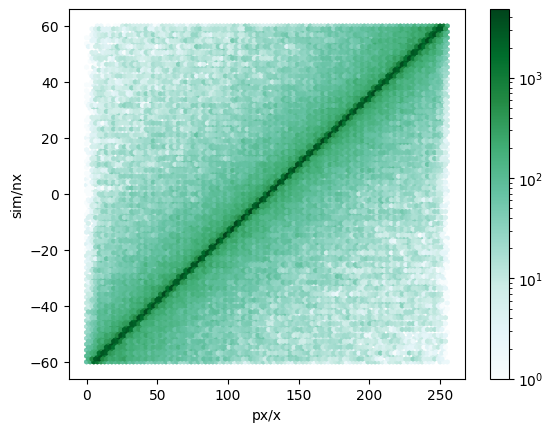

In [50]:
oof.plot.hexbin(x="px/x",y="sim/nx",bins="log")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7601171 entries, 0 to 469066
Data columns (total 25 columns):
 #   Column             Dtype  
---  ------             -----  
 0   px/id              int64  
 1   sim/toa2           float64
 2   sim/id             float64
 3   sim/neutron_id     float64
 4   sim/pulse_id       float64
 5   sim/pulse_time_ns  float64
 6   sim/wavelength     float64
 7   sim/parentName     object 
 8   sim/parentEnergy   float64
 9   sim/neutronEnergy  float64
 10  sim/x              float64
 11  sim/y              float64
 12  sim/z              float64
 13  sim/toa            float64
 14  ph/id              float64
 15  ev/id              float64
 16  ph/x               float64
 17  ph/y               float64
 18  ph/toa             float64
 19  ph/tof             float64
 20  ev/x               float64
 21  ev/y               float64
 22  ev/toa             float64
 23  ev/tof             float64
 24  ev/psd             float64
dtypes: float64(23), int64(1)

# distributions

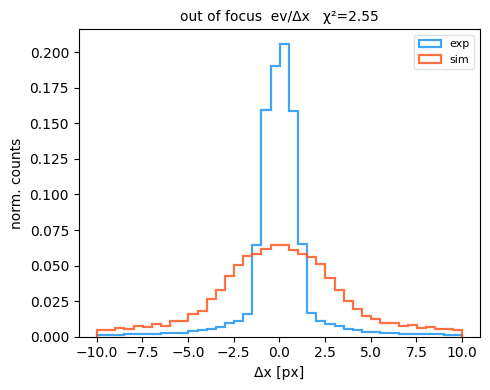

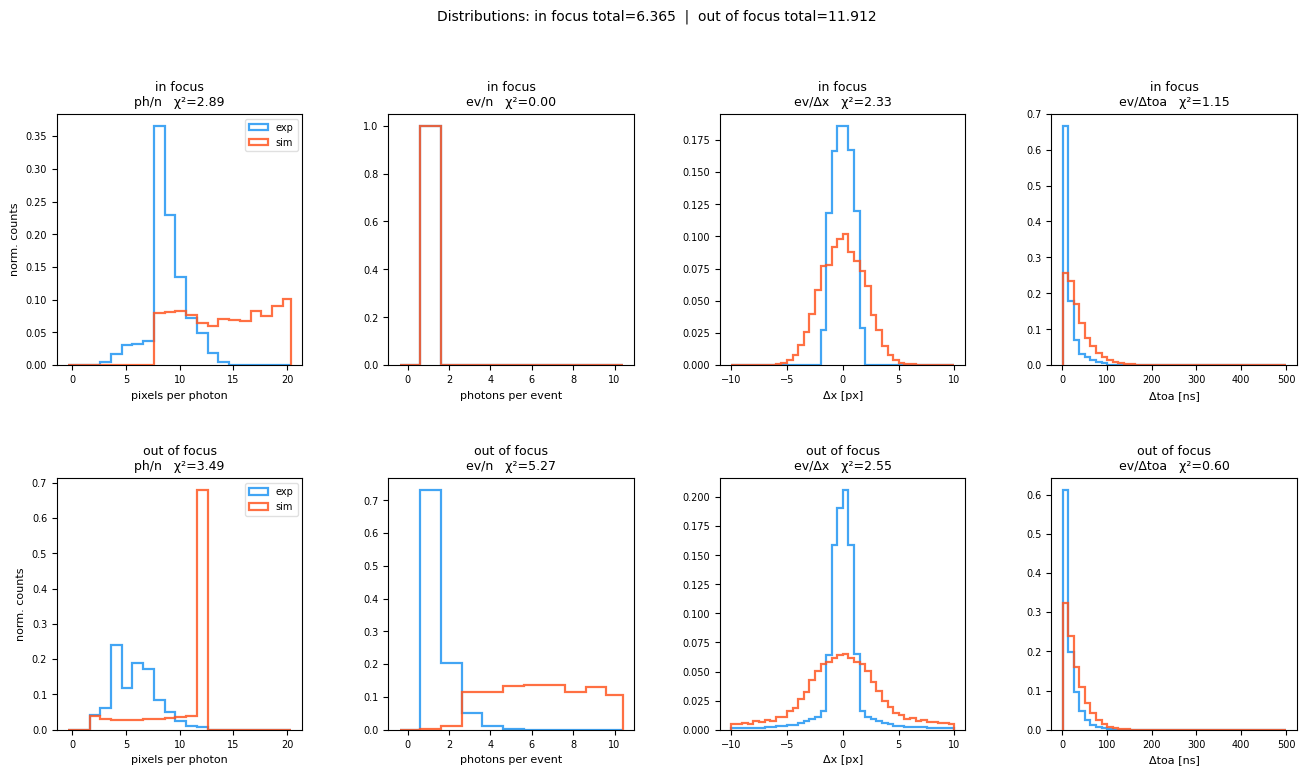

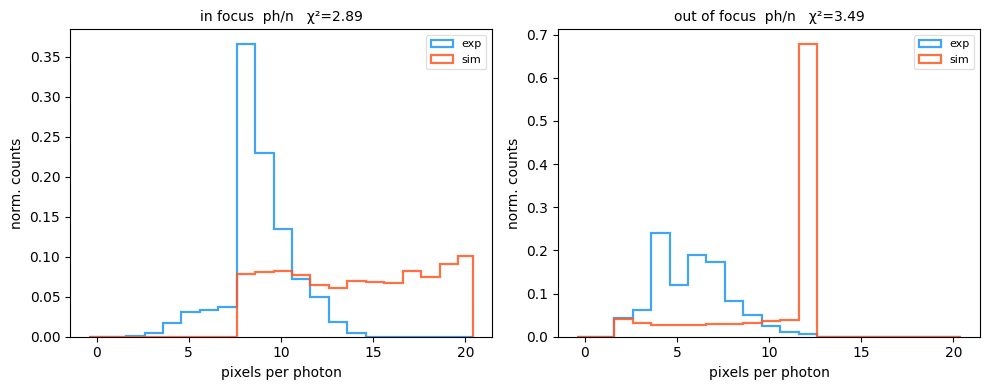

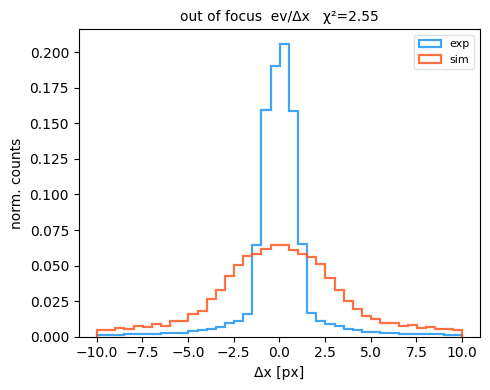

In [39]:
from empindex.plot import DistPlot

dp = DistPlot(inf="archive/openbeam_ptb/z/in_focus.json", 
              oof="archive/openbeam_ptb/z/out_of_focus.json")
# dp = DistPlot.from_val_dir("archive/openbeam_ptb_hs/z30")
dp.plot(kind="all")          # 2×4 grid
dp.plot(kind="ph/n")         # single panel, both rows
dp.plot(kind="ev_dx", focus="out_of_focus")




In [16]:
import json

with open("archive/openbeam_ptb/z/out_of_focus.json","r") as fid:
    oof = json.load(fid)

with open("lumacam_optimize/scan_archive_openbeam_ptb_z30_blob_gain/blob=1.0_gain=10000.0/in_focus.json","r") as fid:
    inf = json.load(fid)

In [17]:
oof['distributions_sim'].keys()

dict_keys(['ph_n', 'ev_n', 'ev_dx', 'ev_dtoa'])

In [18]:
oof.keys()

dict_keys(['sim_path', 'exp_path', 'limit_photons', 'distributions_sim', 'distributions_exp', 'scores', 'alpha', 'n_ph_ratio', 'scale_discrepancy'])

<Axes: >

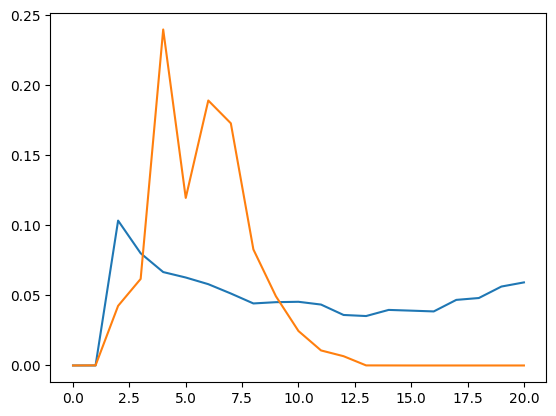

In [19]:
pd.Series(oof['distributions_sim']["ph_n"]).plot(ax=gca())
pd.Series(oof['distributions_exp']["ph_n"]).plot(ax=gca())

<Axes: >

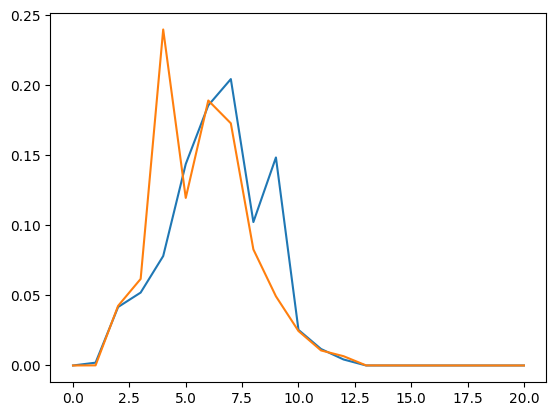

In [105]:
pd.Series(oof['distributions_sim']["ph_n"]).plot(ax=gca())
pd.Series(oof['distributions_exp']["ph_n"]).plot(ax=gca())

<Axes: >

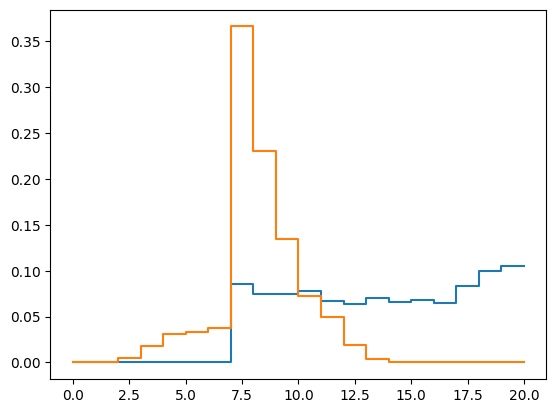

In [82]:
pd.Series(inf['distributions_sim']["ph_n"]).plot(ax=gca(),drawstyle="steps")
pd.Series(inf['distributions_exp']["ph_n"]).plot(ax=gca(),drawstyle="steps")

<Axes: >

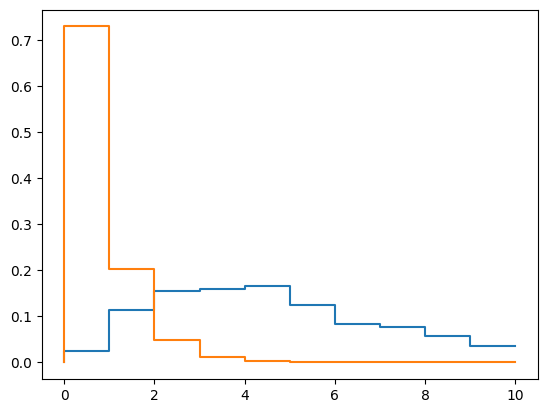

In [83]:
pd.Series(oof['distributions_sim']["ev_n"]).plot(ax=gca(),drawstyle="steps")
pd.Series(oof['distributions_exp']["ev_n"]).plot(ax=gca(),drawstyle="steps")

<Axes: >

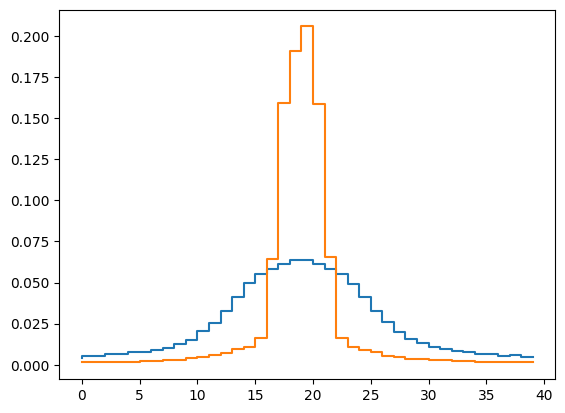

In [84]:
pd.Series(oof['distributions_sim']["ev_dx"]).plot(ax=gca(),drawstyle="steps")
pd.Series(oof['distributions_exp']["ev_dx"]).plot(ax=gca(),drawstyle="steps")

<Axes: >

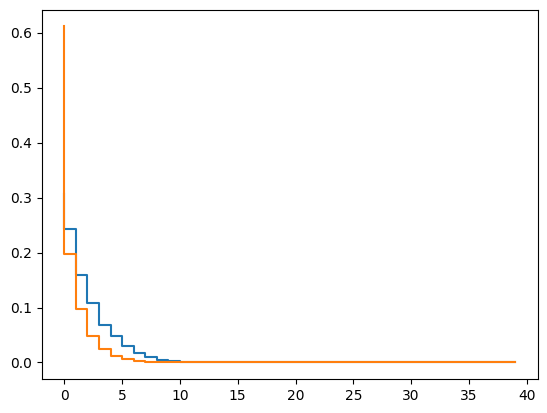

In [85]:
pd.Series(oof['distributions_sim']["ev_dtoa"]).plot(ax=gca(),drawstyle="steps")
pd.Series(oof['distributions_exp']["ev_dtoa"]).plot(ax=gca(),drawstyle="steps")

In [61]:
a = pd.read_json("lumacam_optimize/scan_archive_openbeam_ptb_z30_blob_gain/blob=1.0_gain=10000.0/out_of_focus.json")
a

,sim_path,exp_path,limit_photons,distributions_sim,distributions_exp,scores,alpha,n_ph_ratio,scale_discrepancy
ph_n,../archive/openbeam_ptb/z30/out_of_focus,/work/nuclear/PTB/data/PTB2024/out_of_focus,NaN,"[0.0, 0.0, 0.096332165670719, 0.07958994436431...","[0.0, 8.203580042330474e-05, 0.042551969679568...",2.133805,2.484968,5.803678,3.31871
ev_n,../archive/openbeam_ptb/z30/out_of_focus,/work/nuclear/PTB/data/PTB2024/out_of_focus,NaN,"[0.0, 0.024919668220696002, 0.1132820382798390...","[0.0, 0.7304341404273911, 0.20384680872014402,...",4.204292,2.484968,5.803678,3.31871
ev_dx,../archive/openbeam_ptb/z30/out_of_focus,/work/nuclear/PTB/data/PTB2024/out_of_focus,NaN,"[0.004328469595203, 0.005285776782727, 0.00543...","[0.0013519944622300002, 0.001427706152115, 0.0...",2.578268,2.484968,5.803678,3.31871
ev_dtoa,../archive/openbeam_ptb/z30/out_of_focus,/work/nuclear/PTB/data/PTB2024/out_of_focus,NaN,"[0.305593941738986, 0.24302599819431303, 0.159...","[0.611164662258609, 0.19716689363238102, 0.096...",0.684182,2.484968,5.803678,3.31871
total,../archive/openbeam_ptb/z30/out_of_focus,/work/nuclear/PTB/data/PTB2024/out_of_focus,NaN,NaN,NaN,9.600547,2.484968,5.803678,3.31871


In [59]:
a.set_index(["blob","gain"])["total_in"].unstack()

gain,5000.0,10000.0,15000.0
blob,,,
0.5,4.354188,4.314922,4.295794
1.0,6.345471,6.381577,6.369571
1.5,6.720207,6.791228,6.714671
2.0,6.908176,6.978680,6.972534


In [59]:
a.set_index(["blob","gain"])["total_in"].unstack()

gain,5000.0,10000.0,15000.0
blob,,,
0.5,4.354188,4.314922,4.295794
1.0,6.345471,6.381577,6.369571
1.5,6.720207,6.791228,6.714671
2.0,6.908176,6.978680,6.972534
